# `build_baselines.py`

Giai đoạn 7 (ds) — 4 baseline model Revenue/COGS độc lập (seasonal naive, month-mean, linear, linear+interaction `is_post_2019×month`), backtest holdout 548 ngày (2021-07-02 → 2022-12-31) + production fit full-train + forecast 548 ngày thật (2023-2024), chọn baseline tốt nhất theo WAPE. Notebook unwrap nội dung hàm `main()` thành cell tuần tự (dùng `textwrap.dedent`, không đổi logic), 5 chart hiện inline.

In [1]:
%matplotlib inline
import os
os.chdir(r"/Users/lhoanghai_/Downloads/Dự án datathon2026")
__file__ = r"/Users/lhoanghai_/Downloads/Dự án datathon2026/EDA_Insight/phase7_baseline/build_baselines.py"  # notebook không có __file__ mặc định -> gán thủ công để mọi Path(__file__)... trong code gốc resolve đúng thư mục như khi chạy .py


## Thiết lập / import

In [2]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression

import matplotlib
# matplotlib.use("Agg")  # bỏ trong notebook để %matplotlib inline hiển thị chart
import matplotlib.pyplot as plt

ROOT = Path(__file__).resolve().parents[2]
F6_DIR = ROOT / "EDA_Insight" / "phase6_features" / "data"
OUT_DATA = Path(__file__).resolve().parent / "data"
OUT_CHART = ROOT / "EDA_Insight" / "output" / "phase7"
OUT_DATA.mkdir(parents=True, exist_ok=True)
OUT_CHART.mkdir(parents=True, exist_ok=True)

TARGETS = ["Revenue", "COGS"]

# Feature set B3 — theo thứ tự ưu tiên feature_spec.md mục 5, ĐÃ áp khuyến nghị:
# - bỏ `quarter` (dư thừa với month, feature_spec mục 2)
# - bỏ 3 cờ lễ VN + `dow_cos` (test residual sau, không vào baseline đầu tiên)
# - dùng `day_of_week` dạng cyclical (`dow_sin`) thay vì số nguyên thô
# - chỉ chọn `trend_index` (bỏ `year`) để giảm đa cộng tuyến với `is_post_2019`
BASE_FEATURES = [
    "month_sin", "month_cos", "dow_sin",
    "days_from_tet", "is_post_2019", "is_post_2019_transition",
    "is_low_margin_season", "trend_index", "day_of_month",
]
INTERACTION_FEATURES = ["is_post2019_x_month_sin", "is_post2019_x_month_cos"]

HOLDOUT_MAIN_START = pd.Timestamp("2021-07-02")
HOLDOUT_MAIN_END = pd.Timestamp("2022-12-31")
HOLDOUT_SECONDARY_START = pd.Timestamp("2022-01-01")
HOLDOUT_SECONDARY_END = pd.Timestamp("2022-12-31")

LAG_DAYS = 365  # seasonal naive period

## Hàm hỗ trợ (`add_interaction`, `calc_metrics`, `seasonal_naive_predict`, `fit_month_mean`, `predict_month_mean`, `fit_linear`, `ols_coeff_table`)

In [3]:
def add_interaction(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["is_post2019_x_month_sin"] = df["is_post_2019"] * df["month_sin"]
    df["is_post2019_x_month_cos"] = df["is_post_2019"] * df["month_cos"]
    return df


def calc_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    err = y_true - y_pred
    n_zero = int((np.abs(y_true) < 1e-9).sum())
    mape = np.mean(np.abs(err) / np.abs(y_true)) * 100 if n_zero == 0 else np.nan
    wape = np.sum(np.abs(err)) / np.sum(np.abs(y_true)) * 100
    rmse = np.sqrt(np.mean(err ** 2))
    mae = np.mean(np.abs(err))
    return {"MAPE": mape, "WAPE": wape, "RMSE": rmse, "MAE": mae, "n_zero_actual": n_zero}


def seasonal_naive_predict(history: pd.Series, dates_to_predict: pd.DatetimeIndex, lag_days: int = LAG_DAYS) -> pd.Series:
    """ŷ(t) = giá trị tại (t - lag_days). Nếu thiếu đúng ngày lag (hiếm, do
    biên dữ liệu), tìm ngày gần nhất trong +-3 ngày; nếu vẫn không có, dùng
    trung bình toàn lịch sử làm phương án cuối. Sau khi dự đoán ngày t, GIÁ TRỊ
    DỰ ĐOÁN (không phải actual) được thêm vào `history` để các ngày xa hơn horizon
    (t + lag_days trở lên) có thể tham chiếu — cần thiết khi horizon > lag_days
    (VD dự báo 548 ngày > 365 ngày lag). Đây là hành vi chuẩn của seasonal naive
    khi horizon dài hơn 1 chu kỳ mùa vụ — không phải leakage vì không dùng actual
    thật của tương lai, chỉ chain lại dự đoán của chính baseline.
    """
    hist = history.copy()
    preds = {}
    global_mean = hist.mean()
    for d in sorted(dates_to_predict):
        lag_date = d - pd.Timedelta(days=lag_days)
        val = None
        if lag_date in hist.index:
            val = hist.loc[lag_date]
        else:
            for delta in range(1, 4):
                for cand in (lag_date - pd.Timedelta(days=delta), lag_date + pd.Timedelta(days=delta)):
                    if cand in hist.index:
                        val = hist.loc[cand]
                        break
                if val is not None:
                    break
        if val is None:
            val = global_mean
        preds[d] = val
        hist.loc[d] = val
    return pd.Series(preds).sort_index()


def fit_month_mean(train_df: pd.DataFrame, target: str) -> pd.Series:
    return train_df.groupby("month")[target].mean()


def predict_month_mean(month_means: pd.Series, df: pd.DataFrame) -> np.ndarray:
    return df["month"].map(month_means).to_numpy()


def fit_linear(train_df: pd.DataFrame, feature_cols: list[str], target: str) -> LinearRegression:
    X = train_df[feature_cols].to_numpy()
    y = train_df[target].to_numpy()
    return LinearRegression().fit(X, y)


def predict_linear(model: LinearRegression, df: pd.DataFrame, feature_cols: list[str]) -> np.ndarray:
    return model.predict(df[feature_cols].to_numpy())


def ols_coeff_table(train_df: pd.DataFrame, feature_cols: list[str], target: str) -> pd.DataFrame:
    X = sm.add_constant(train_df[feature_cols].to_numpy())
    y = train_df[target].to_numpy()
    res = sm.OLS(y, X).fit()
    names = ["const"] + feature_cols
    return pd.DataFrame({
        "target": target,
        "feature": names,
        "coef": res.params,
        "std_err": res.bse,
        "p_value": res.pvalues,
    })

## Chạy pipeline (tương đương nội dung hàm `main()` — unwrap thành cell notebook bằng `textwrap.dedent`, KHÔNG đổi logic). Load `features_train`/`features_forecast`, split train/holdout (không leakage), quyết định loại 181 ngày 2012 khỏi fit B3/B3b

In [4]:
train_full = pd.read_csv(F6_DIR / "features_train.csv", parse_dates=["Date"]).sort_values("Date").reset_index(drop=True)
forecast_df = pd.read_csv(F6_DIR / "features_forecast.csv", parse_dates=["Date"]).sort_values("Date").reset_index(drop=True)
sample_sub = pd.read_csv(ROOT / "data" / "sample_submission.csv")

print(f"[load] train_full: {train_full.shape}, forecast: {forecast_df.shape}")
assert set(forecast_df["Date"].dt.strftime("%Y-%m-%d")) == set(sample_sub["Date"]), "forecast dates lệch sample_submission"

# ---------------- Split (KHÔNG leakage) ----------------
train_fit = train_full[train_full["Date"] < HOLDOUT_MAIN_START].copy()
holdout_main = train_full[(train_full["Date"] >= HOLDOUT_MAIN_START) & (train_full["Date"] <= HOLDOUT_MAIN_END)].copy()
holdout_main["in_2022"] = (holdout_main["Date"] >= HOLDOUT_SECONDARY_START) & (holdout_main["Date"] <= HOLDOUT_SECONDARY_END)

print(f"[split] train_fit: {train_fit['Date'].min().date()} -> {train_fit['Date'].max().date()} ({len(train_fit)} ngày)")
print(f"[split] holdout_main: {holdout_main['Date'].min().date()} -> {holdout_main['Date'].max().date()} ({len(holdout_main)} ngày)")
print(f"[split] holdout_secondary (subset, 2022 full year): {int(holdout_main['in_2022'].sum())} ngày")

# Quyết định 2012 (nửa năm, `is_partial_year_2012`):
# - B1 (seasonal naive) và B2 (moving average theo tháng): GIỮ 2012, vì 2 baseline
#   này không dùng year/trend_index — 181 ngày 2012 (T7-T12) chỉ bổ sung thêm quan
#   sát cho các tháng đã có ở năm khác, không gây lệch hệ số nào.
# - B3/B3b (linear, có `trend_index`): LOẠI 181 ngày 2012 khỏi fit — theo cảnh báo
#   feature_spec.md mục 5 (2012 thiếu nửa năm cao điểm T1-T6, Revenue trung bình
#   thấp bất thường so nhóm pre-break, sẽ kéo lệch hệ số trend nếu giữ).
train_fit_b3 = train_fit[train_fit["is_partial_year_2012"] == 0].copy()
train_full_b3 = train_full[train_full["is_partial_year_2012"] == 0].copy()
print(f"[decision] B3/B3b loại {int((train_fit['is_partial_year_2012']==1).sum())} ngày 2012 khỏi fit "
      f"(train_fit: {len(train_fit)} -> {len(train_fit_b3)} ngày dùng cho linear model)")

holdout_main_int = add_interaction(holdout_main)
forecast_df_int = add_interaction(forecast_df)
train_fit_b3_int = add_interaction(train_fit_b3)
train_full_b3_int = add_interaction(train_full_b3)
b3b_features = BASE_FEATURES + INTERACTION_FEATURES

[load] train_full: (3833, 21), forecast: (548, 18)
[split] train_fit: 2012-07-04 -> 2021-07-01 (3285 ngày)
[split] holdout_main: 2021-07-02 -> 2022-12-31 (548 ngày)
[split] holdout_secondary (subset, 2022 full year): 365 ngày
[decision] B3/B3b loại 181 ngày 2012 khỏi fit (train_fit: 3285 -> 3104 ngày dùng cho linear model)


### Fit 4 baseline (B1 seasonal naive, B2 month-mean, B3 linear, B3b linear+interaction) cho Revenue và COGS — backtest holdout + production fit full-train

In [5]:
all_metrics_rows = []
holdout_pred_rows = []
coeff_rows = []
forecast_store = {"B1_seasonal_naive": {}, "B2_month_mean": {}, "B3_linear": {}, "B3b_linear_interaction": {}}
train_fitted_store = {}  # for actual-vs-fitted chart (B3, full-train fit)

for target in TARGETS:
    print(f"\n==== Target: {target} ====")

    # ---------------- B1 seasonal naive (backtest) ----------------
    hist_series_bt = train_fit.set_index("Date")[target].sort_index()
    b1_hold = seasonal_naive_predict(hist_series_bt, pd.DatetimeIndex(holdout_main["Date"]))
    b1_hold = b1_hold.reindex(holdout_main["Date"]).to_numpy()

    # ---------------- B2 month-mean (backtest) ----------------
    month_means_bt = fit_month_mean(train_fit, target)
    b2_hold = predict_month_mean(month_means_bt, holdout_main)

    # ---------------- B3 linear (backtest) ----------------
    model_b3_bt = fit_linear(train_fit_b3, BASE_FEATURES, target)
    b3_hold = predict_linear(model_b3_bt, holdout_main, BASE_FEATURES)

    # ---------------- B3b linear + interaction (backtest) ----------------
    model_b3b_bt = fit_linear(train_fit_b3_int, b3b_features, target)
    b3b_hold = predict_linear(model_b3b_bt, holdout_main_int, b3b_features)

    preds = {
        "B1_seasonal_naive": b1_hold,
        "B2_month_mean": b2_hold,
        "B3_linear": b3_hold,
        "B3b_linear_interaction": b3b_hold,
    }
    y_true_main = holdout_main[target].to_numpy()
    y_true_sec = holdout_main.loc[holdout_main["in_2022"], target].to_numpy()

    for name, pred in preds.items():
        m_main = calc_metrics(y_true_main, pred)
        m_sec = calc_metrics(y_true_sec, pred[holdout_main["in_2022"].to_numpy()])
        all_metrics_rows.append({"baseline": name, "target": target, "holdout": "main_548d", **m_main})
        all_metrics_rows.append({"baseline": name, "target": target, "holdout": "secondary_2022", **m_sec})

    for i, d in enumerate(holdout_main["Date"]):
        holdout_pred_rows.append({
            "Date": d.strftime("%Y-%m-%d"), "target": target, "actual": y_true_main[i],
            "in_2022": bool(holdout_main["in_2022"].iloc[i]),
            "B1_seasonal_naive": b1_hold[i], "B2_month_mean": b2_hold[i],
            "B3_linear": b3_hold[i], "B3b_linear_interaction": b3b_hold[i],
        })

    # ---------------- OLS coefficient table (B3, full production fit) ----------------
    coeff_rows.append(ols_coeff_table(train_full_b3, BASE_FEATURES, target))

    # ---------------- Production fit (dùng FULL train, không leakage vì đây là forecast thật) ----------------
    hist_series_full = train_full.set_index("Date")[target].sort_index()
    b1_fc = seasonal_naive_predict(hist_series_full, pd.DatetimeIndex(forecast_df["Date"]))
    b1_fc = b1_fc.reindex(forecast_df["Date"]).to_numpy()

    month_means_full = fit_month_mean(train_full, target)
    b2_fc = predict_month_mean(month_means_full, forecast_df)

    model_b3_full = fit_linear(train_full_b3, BASE_FEATURES, target)
    b3_fc = predict_linear(model_b3_full, forecast_df, BASE_FEATURES)

    model_b3b_full = fit_linear(train_full_b3_int, b3b_features, target)
    b3b_fc = predict_linear(model_b3b_full, forecast_df_int, b3b_features)

    forecast_store["B1_seasonal_naive"][target] = b1_fc
    forecast_store["B2_month_mean"][target] = b2_fc
    forecast_store["B3_linear"][target] = b3_fc
    forecast_store["B3b_linear_interaction"][target] = b3b_fc

    # fitted trên toàn bộ train (production fit B3) — cho chart actual vs fitted
    train_fitted_store[target] = {
        "Date": train_full_b3["Date"].to_numpy(),
        "actual": train_full_b3[target].to_numpy(),
        "fitted": predict_linear(model_b3_full, train_full_b3, BASE_FEATURES),
    }


==== Target: Revenue ====



==== Target: COGS ====


### Lưu metrics + predictions + OLS coefficient table

In [6]:
metrics_df = pd.DataFrame(all_metrics_rows)
metrics_df.to_csv(OUT_DATA / "metrics_summary.csv", index=False)
print("\n[Bảng metric — holdout main 548 ngày]")
print(metrics_df[metrics_df["holdout"] == "main_548d"].round(3).to_string(index=False))
print("\n[Bảng metric — holdout secondary 2022 (365 ngày)]")
print(metrics_df[metrics_df["holdout"] == "secondary_2022"].round(3).to_string(index=False))

pd.DataFrame(holdout_pred_rows).to_csv(OUT_DATA / "holdout_predictions.csv", index=False)
pd.concat(coeff_rows, ignore_index=True).round(4).to_csv(OUT_DATA / "b3_ols_coefficients.csv", index=False)


[Bảng metric — holdout main 548 ngày]
              baseline  target   holdout   MAPE   WAPE        RMSE         MAE  n_zero_actual
     B1_seasonal_naive Revenue main_548d 27.479 25.181 1022856.302  724009.371              0
         B2_month_mean Revenue main_548d 78.680 56.506 1899771.180 1624687.859              0
             B3_linear Revenue main_548d 56.930 46.971 1650677.721 1350528.567              0
B3b_linear_interaction Revenue main_548d 59.729 46.543 1590459.489 1338229.620              0
     B1_seasonal_naive    COGS main_548d 24.082 23.093  830134.372  601979.838              0
         B2_month_mean    COGS main_548d 70.797 52.218 1591632.278 1361207.001              0
             B3_linear    COGS main_548d 50.459 42.277 1389626.684 1102071.392              0
B3b_linear_interaction    COGS main_548d 52.161 41.220 1332933.729 1074510.847              0

[Bảng metric — holdout secondary 2022 (365 ngày)]
              baseline  target        holdout   MAPE   WAPE     

### Xuất forecast 548 ngày cho từng baseline

In [7]:
# ---------------- Xuất forecast 548 ngày cho từng baseline ----------------
for name, target_preds in forecast_store.items():
    out = pd.DataFrame({
        "Date": forecast_df["Date"].dt.strftime("%Y-%m-%d"),
        "Revenue": np.round(target_preds["Revenue"], 2),
        "COGS": np.round(target_preds["COGS"], 2),
    })
    out.to_csv(OUT_DATA / f"forecast_{name}.csv", index=False)

### Chọn baseline tốt nhất theo WAPE trung bình (Revenue+COGS, holdout main)

In [8]:
# ---------------- Chọn baseline tốt nhất (trung bình WAPE Revenue+COGS, holdout main) ----------------
main_wape = (metrics_df[metrics_df["holdout"] == "main_548d"]
             .pivot_table(index="baseline", columns="target", values="WAPE"))
main_wape["avg_WAPE"] = main_wape.mean(axis=1)
best_name = main_wape["avg_WAPE"].idxmin()
print(f"\n[Chọn baseline tốt nhất] theo avg WAPE (Revenue+COGS) holdout main:\n{main_wape.round(3).to_string()}")
print(f"--> BEST: {best_name} (avg WAPE = {main_wape.loc[best_name, 'avg_WAPE']:.3f}%)")

best_forecast = pd.read_csv(OUT_DATA / f"forecast_{best_name}.csv")
best_forecast.to_csv(OUT_DATA / "submission_best_baseline.csv", index=False)
with open(OUT_DATA / "best_baseline_name.txt", "w") as f:
    f.write(best_name + "\n")


[Chọn baseline tốt nhất] theo avg WAPE (Revenue+COGS) holdout main:
target                    COGS  Revenue  avg_WAPE
baseline                                         
B1_seasonal_naive       23.093   25.181    24.137
B2_month_mean           52.218   56.506    54.362
B3_linear               42.277   46.971    44.624
B3b_linear_interaction  41.220   46.543    43.882
--> BEST: B1_seasonal_naive (avg WAPE = 24.137%)


### Chart 1 — Actual vs Fitted trên train (B3 linear, production fit)

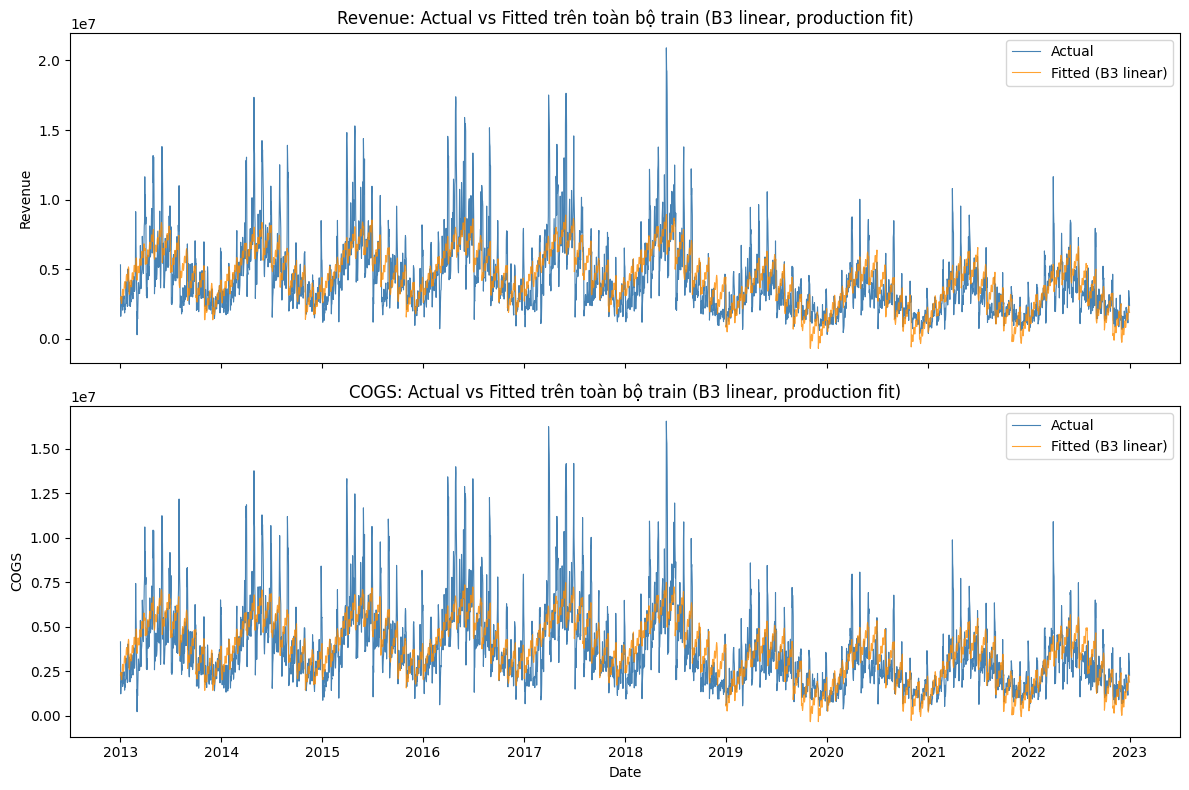

In [9]:
# --- Chart 1: actual vs fitted trên train (B3, production fit) ---
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
for ax, target in zip(axes, TARGETS):
    d = train_fitted_store[target]
    ax.plot(d["Date"], d["actual"], label="Actual", color="steelblue", linewidth=0.8)
    ax.plot(d["Date"], d["fitted"], label="Fitted (B3 linear)", color="darkorange", linewidth=0.8, alpha=0.8)
    ax.set_title(f"{target}: Actual vs Fitted trên toàn bộ train (B3 linear, production fit)")
    ax.set_ylabel(target)
    ax.legend()
axes[-1].set_xlabel("Date")
fig.tight_layout()
fig.savefig(OUT_CHART / "07_train_fit_vs_actual.png", dpi=120)
plt.show()
plt.close(fig)

**Phân tích Chart 1 — Actual vs Fitted trên toàn bộ train (B3 linear, production fit)**

1. **Thể hiện gì:** 2 panel (Revenue, COGS) — đường xanh là giá trị thật `sales.csv` 2013-2022 (bỏ 2012), đường cam là giá trị B3 linear dự đoán trên chính tập nó được fit (production fit, dùng toàn bộ `train_full_b3`).
2. **Insight:** đường cam bắt được hình dạng mùa vụ (đỉnh giữa năm, đáy cuối năm) và mức nền thấp hơn rõ rệt sau 2019 — xác nhận `month_sin/cos` + `is_post_2019` hoạt động đúng hướng. Nhưng đường cam mượt hơn nhiều so với đường xanh (không bắt được các đỉnh nhọn/spike ngày lẻ) — linear model chỉ giải thích được phần "trung bình có điều kiện", bỏ sót biến động ngày-qua-ngày.
3. **Lưu ý:** một số đoạn đường cam đi xuống dưới 0 (rõ nhất quanh 2019-2022, COGS) — dấu hiệu linear model không có ràng buộc không-âm, ảnh hưởng tới cả forecast (xem Chart 3). Không đọc biểu đồ này như "model tốt" chỉ vì bám sát trend chung — bám sát train KHÔNG đồng nghĩa dự báo tốt trên dữ liệu chưa thấy.


### Chart 2 — Actual vs Predicted trên holdout main (4 baseline)

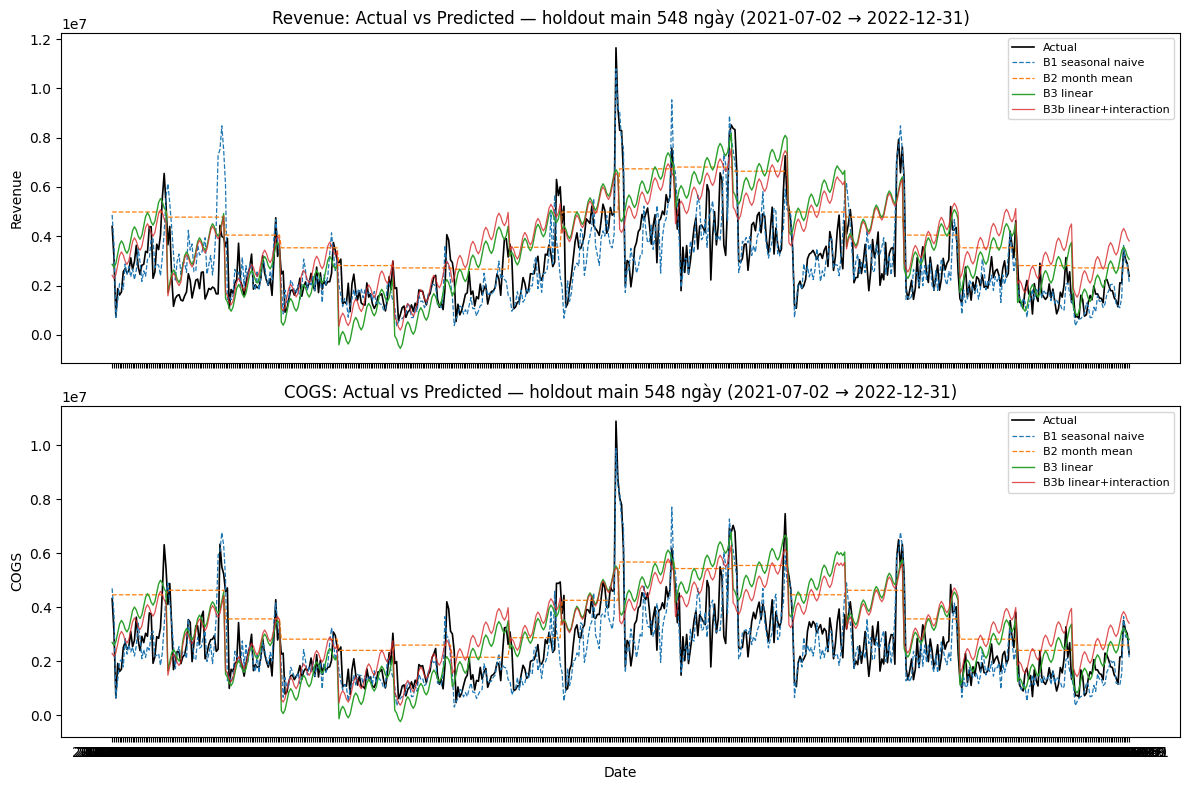

In [10]:
# --- Chart 2: actual vs predicted trên holdout main (mọi baseline) ---
hp = pd.DataFrame(holdout_pred_rows)
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
for ax, target in zip(axes, TARGETS):
    sub = hp[hp["target"] == target].sort_values("Date")
    ax.plot(sub["Date"], sub["actual"], label="Actual", color="black", linewidth=1.2)
    ax.plot(sub["Date"], sub["B1_seasonal_naive"], label="B1 seasonal naive", linestyle="--", linewidth=0.9)
    ax.plot(sub["Date"], sub["B2_month_mean"], label="B2 month mean", linestyle="--", linewidth=0.9)
    ax.plot(sub["Date"], sub["B3_linear"], label="B3 linear", linewidth=1.0)
    ax.plot(sub["Date"], sub["B3b_linear_interaction"], label="B3b linear+interaction", linewidth=0.9, alpha=0.8)
    ax.set_title(f"{target}: Actual vs Predicted — holdout main 548 ngày (2021-07-02 → 2022-12-31)")
    ax.set_ylabel(target)
    ax.legend(fontsize=8)
axes[-1].set_xlabel("Date")
fig.tight_layout()
fig.savefig(OUT_CHART / "07_holdout_actual_vs_pred.png", dpi=120)
plt.show()
plt.close(fig)

**Phân tích Chart 2 — Actual vs Predicted trên holdout main (4 baseline)**

1. **Thể hiện gì:** đường đen là Actual (holdout 2021-07-02 → 2022-12-31), 4 đường màu là 4 baseline dự đoán cùng khoảng thời gian, 2 panel Revenue/COGS.
2. **Insight:** đường B1 (seasonal naive) bám sát biến động lên-xuống của Actual tốt hơn hẳn — kể cả spike đột biến giữa 2022 B1 cũng nhô lên theo. B2 (month-mean) là đường bậc thang phẳng theo tháng, hoàn toàn không phản ứng với xu hướng phục hồi 2022 — sai nhiều nhất. B3/B3b nằm cao hơn Actual khá rõ trong phần lớn giai đoạn, đặc biệt rõ nửa sau 2022 — xác nhận linear model bị lệch (bias) hướng lên.
3. **Lưu ý:** trục ngày dày đặc (548 điểm) nên chỉ nên đọc xu hướng tổng thể (đường nào bám actual, đường nào lệch hệ thống), không cố đọc giá trị chính xác 1 ngày cụ thể (dùng `data/holdout_predictions.csv` nếu cần số chính xác).


### Chart 3 — Forecast 548 ngày, 4 baseline chồng nhau

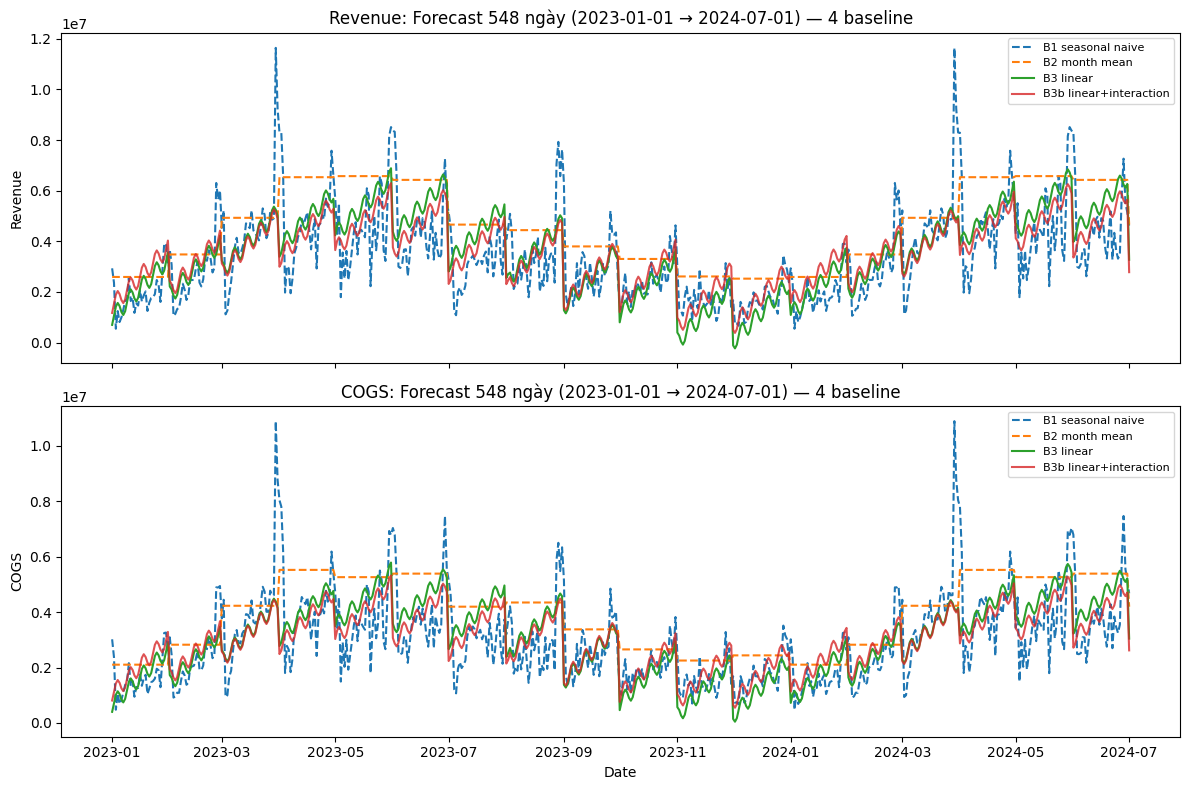

In [11]:
# --- Chart 3: forecast 548 ngày, 3 baseline chồng nhau ---
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
for ax, target in zip(axes, TARGETS):
    ax.plot(forecast_df["Date"], forecast_store["B1_seasonal_naive"][target], label="B1 seasonal naive", linestyle="--")
    ax.plot(forecast_df["Date"], forecast_store["B2_month_mean"][target], label="B2 month mean", linestyle="--")
    ax.plot(forecast_df["Date"], forecast_store["B3_linear"][target], label="B3 linear")
    ax.plot(forecast_df["Date"], forecast_store["B3b_linear_interaction"][target], label="B3b linear+interaction", alpha=0.8)
    ax.set_title(f"{target}: Forecast 548 ngày (2023-01-01 → 2024-07-01) — 4 baseline")
    ax.set_ylabel(target)
    ax.legend(fontsize=8)
axes[-1].set_xlabel("Date")
fig.tight_layout()
fig.savefig(OUT_CHART / "07_forecast_baselines_overlay.png", dpi=120)
plt.show()
plt.close(fig)

**Phân tích Chart 3 — Forecast 548 ngày, 4 baseline chồng nhau**

1. **Thể hiện gì:** dự báo thật 2023-01-01 → 2024-07-01 (không có actual để so sánh) của cả 4 baseline, 2 panel Revenue/COGS.
2. **Insight:** hình dạng mùa vụ lặp lại rõ ràng ở cả 4 baseline (đỉnh giữa mỗi năm, đáy cuối năm khớp `is_low_margin_season`). B1 dao động biên độ rộng nhất (giữ nguyên độ nhiễu ngày-qua-ngày của năm gốc dùng làm lag), B2 là bậc thang phẳng theo tháng, B3/B3b mượt nhưng nhỉnh cao hơn B1 ở phần lớn thời gian — nhất quán với bias đã thấy ở Chart 2.
3. **Lưu ý:** đường B3 có 4 ngày dự đoán **Revenue ÂM** (thấp nhất -231,484 VND, ngày 2023-12-02) — khó thấy rõ trên chart vì chỉ vài điểm chạm/xuống dưới 0, nhưng đây là lỗi cấu trúc thật của linear regression (không ràng buộc không-âm) — **không dùng B3 làm submission cuối nếu không xử lý floor tại 0**. B3b không có ngày nào âm nhờ interaction term.


### Chart 4 — Residual của B3 linear trên holdout main

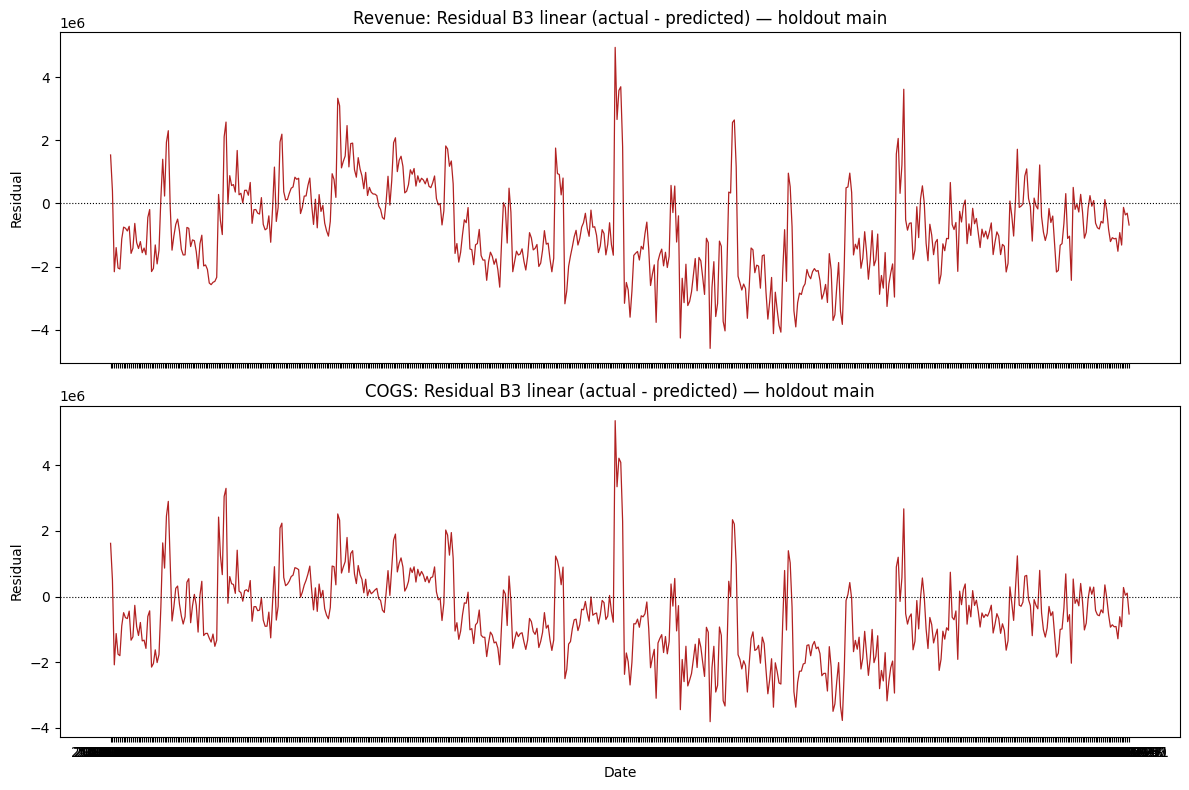

In [12]:
# --- Chart 4: residual của B3 trên holdout main ---
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
for ax, target in zip(axes, TARGETS):
    sub = hp[hp["target"] == target].sort_values("Date")
    resid = sub["actual"] - sub["B3_linear"]
    ax.plot(sub["Date"], resid, color="firebrick", linewidth=0.9)
    ax.axhline(0, color="black", linewidth=0.8, linestyle=":")
    ax.set_title(f"{target}: Residual B3 linear (actual - predicted) — holdout main")
    ax.set_ylabel("Residual")
axes[-1].set_xlabel("Date")
fig.tight_layout()
fig.savefig(OUT_CHART / "07_b3_residuals_holdout.png", dpi=120)
plt.show()
plt.close(fig)

**Phân tích Chart 4 — Residual của B3 linear trên holdout main**

1. **Thể hiện gì:** `actual − predicted` (B3 linear) theo ngày, holdout chính, đường 0 là mốc tham chiếu — 2 panel Revenue/COGS.
2. **Insight:** residual **lệch âm mang tính hệ thống** (đa số điểm nằm dưới 0), rõ nhất nửa sau giai đoạn — actual < predicted đa số ngày. Cụ thể: Revenue actual trung bình holdout chính = 2,875,239 nhưng B3 dự đoán trung bình 3,712,559 (lệch +29%); riêng 2022, actual 3,204,791 nhưng B3 dự đoán 4,461,063 (lệch +39%). Nguyên nhân: `trend_index` là 1 hệ số tuyến tính DUY NHẤT ước lượng trên toàn 2013-2022, là compromise giữa xu hướng TĂNG 2013-2018 và GIẢM/phục hồi chậm 2019-2022 — khi ngoại suy tới 2021-2022 (và xa hơn tới 2023-2024), vẫn cộng thêm độ dốc dương của giai đoạn tăng cũ.
3. **Lưu ý:** residual không phân bố ngẫu nhiên quanh 0 (có pattern rõ theo thời gian) — dấu hiệu model **underfit theo trend cấu trúc**, không phải nhiễu đo lường. Không dùng RMSE/MAE của B3 như thước đo "sai số ngẫu nhiên" thông thường; bias hệ thống này còn nguy hiểm hơn cho horizon 2023-2024 thật vì càng xa mốc train (`trend_index` càng lớn), sai lệch ngoại suy càng có khả năng tích luỹ thêm.


### Chart 5 — So sánh MAPE/WAPE giữa 4 baseline (holdout main)

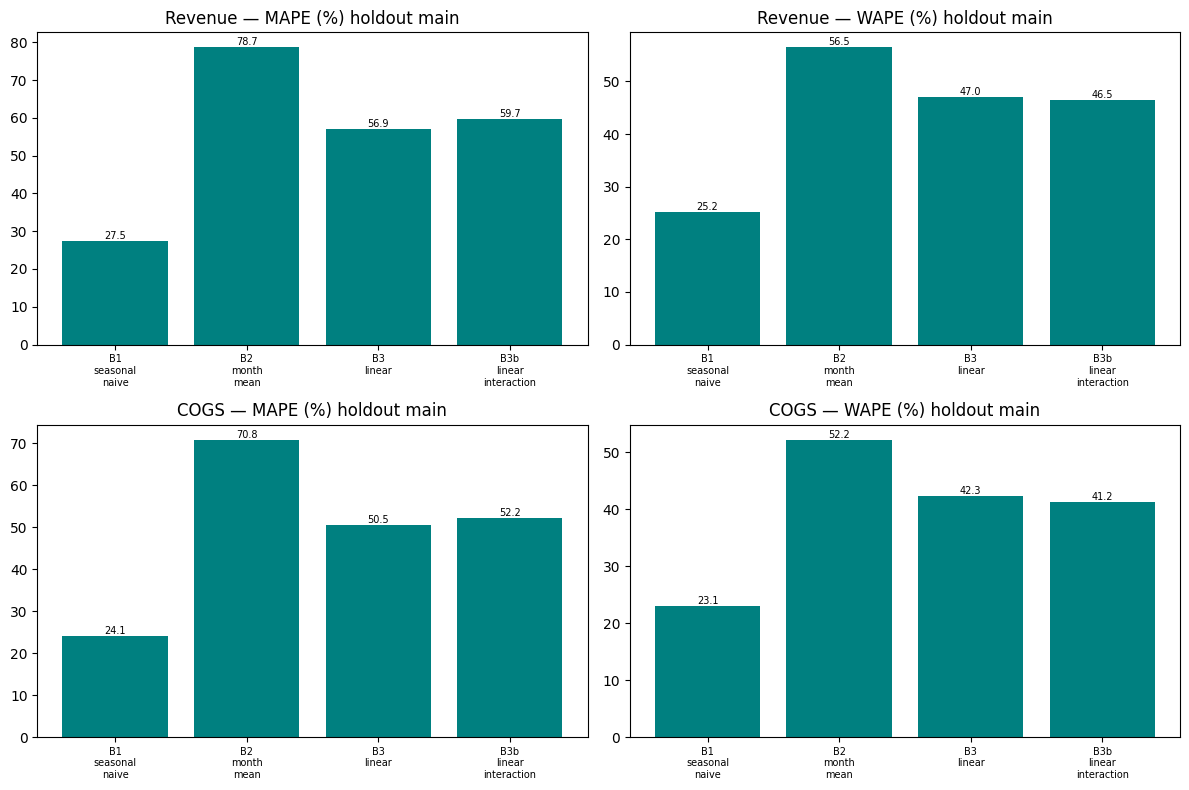

In [13]:
# --- Chart 5: bar so MAPE/WAPE giữa baseline (holdout main) ---
main_m = metrics_df[metrics_df["holdout"] == "main_548d"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
baselines_order = ["B1_seasonal_naive", "B2_month_mean", "B3_linear", "B3b_linear_interaction"]
for row, target in enumerate(TARGETS):
    for col, metric in enumerate(["MAPE", "WAPE"]):
        ax = axes[row, col]
        sub = main_m[main_m["target"] == target].set_index("baseline").reindex(baselines_order)
        ax.bar(range(len(baselines_order)), sub[metric], color="teal")
        ax.set_xticks(range(len(baselines_order)))
        ax.set_xticklabels([b.replace("_", "\n") for b in baselines_order], fontsize=7)
        ax.set_title(f"{target} — {metric} (%) holdout main")
        for i, v in enumerate(sub[metric]):
            ax.text(i, v, f"{v:.1f}", ha="center", va="bottom", fontsize=7)
fig.tight_layout()
fig.savefig(OUT_CHART / "07_metric_bar_comparison.png", dpi=120)
plt.show()
plt.close(fig)

**Phân tích Chart 5 — So sánh MAPE/WAPE giữa 4 baseline (holdout main)**

1. **Thể hiện gì:** 4 panel (Revenue×MAPE, Revenue×WAPE, COGS×MAPE, COGS×WAPE), mỗi panel 4 cột ứng 4 baseline, số ghi trên đầu cột, tính trên holdout chính.
2. **Insight:** thứ tự nhất quán ở cả 4 panel: **B1 thấp nhất (tốt nhất) → B3b ≈ B3 → B2 cao nhất (tệ nhất)**. Khoảng cách B1 so với B3/B3b rất lớn (WAPE Revenue: 25.2% vs ~47%, gần gấp đôi), không phải chênh lệch nhỏ trong biên sai số ngẫu nhiên.
3. **Lưu ý:** MAPE luôn cao hơn WAPE ở cả 4 baseline (đúng tính chất toán học — MAPE nhạy với ngày actual nhỏ, WAPE cân bằng theo tổng biên độ) → nên dùng WAPE làm chỉ số chính để so sánh, MAPE chỉ tham khảo thêm. B2 tệ nhất không có nghĩa "mùa vụ vô dụng" — vì B2 hoàn toàn bỏ qua trend/break, chỉ dùng trung bình lịch sử toàn giai đoạn (bao gồm cả các năm doanh thu cao trước break) nên bị lệch nặng lên trên so với mức nền thấp hơn sau 2019.


### Hoàn tất

In [14]:
print("\nHoàn tất Giai đoạn 7. File output:")
for p in sorted(OUT_DATA.glob("*")):
    print(f" - {p}")
for p in sorted(OUT_CHART.glob("07_*.png")):
    print(f" - {p}")


Hoàn tất Giai đoạn 7. File output:
 - /Users/lhoanghai_/Downloads/Dự án datathon2026/EDA_Insight/phase7_baseline/data/b3_ols_coefficients.csv
 - /Users/lhoanghai_/Downloads/Dự án datathon2026/EDA_Insight/phase7_baseline/data/best_baseline_name.txt
 - /Users/lhoanghai_/Downloads/Dự án datathon2026/EDA_Insight/phase7_baseline/data/forecast_B1_seasonal_naive.csv
 - /Users/lhoanghai_/Downloads/Dự án datathon2026/EDA_Insight/phase7_baseline/data/forecast_B2_month_mean.csv
 - /Users/lhoanghai_/Downloads/Dự án datathon2026/EDA_Insight/phase7_baseline/data/forecast_B3_linear.csv
 - /Users/lhoanghai_/Downloads/Dự án datathon2026/EDA_Insight/phase7_baseline/data/forecast_B3b_linear_interaction.csv
 - /Users/lhoanghai_/Downloads/Dự án datathon2026/EDA_Insight/phase7_baseline/data/holdout_predictions.csv
 - /Users/lhoanghai_/Downloads/Dự án datathon2026/EDA_Insight/phase7_baseline/data/metrics_summary.csv
 - /Users/lhoanghai_/Downloads/Dự án datathon2026/EDA_Insight/phase7_baseline/data/submissio